In [24]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [25]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [26]:
load_dotenv()

True

In [27]:
llm = ChatOpenAI(model='gpt-4o-mini')

In [28]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [29]:
len(docs)

392

In [30]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [31]:
len(chunks)

973

In [32]:
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store = FAISS.from_documents(chunks, embeddings)

In [33]:
vector_store

In [34]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [35]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [36]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [37]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [38]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [39]:
tool_node = ToolNode(tools)

In [40]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

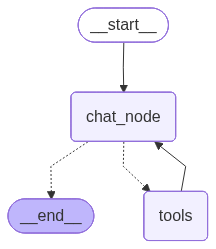

In [41]:
chatbot

In [42]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [43]:
print(result['messages'][-1].content)

To find the ideal value of K in the k-nearest neighbors (KNN) algorithm, consider the following points derived from the context of the material:

1. **Understanding K**:
   - The 'k' in KNN represents the number of nearest neighbors used to make predictions. Instead of relying on only one neighbor, the algorithm looks at the k closest neighbors and assesses the majority class label among them.

2. **Choosing K**:
   - A smaller value of K (like K=1) can be sensitive to noise in the data, while a larger K might smooth over distinctions between classes. Therefore, it's crucial to choose K thoughtfully.
   - The value of K affects the performance of the model; a too-low K can lead to overfitting, while a too-high K can lead to underfitting.

3. **Determining the Ideal K**:
   - There isn't a one-size-fits-all answer for the ideal value of K; it largely depends on the dataset. 
   - A common approach to find the best K is to use cross-validation. This involves testing a range of K values (